In [119]:
import os
import torch
import rasterio
import numpy as np
from pathlib import Path
import h5py
from typing import Dict, Any
import matplotlib.pyplot as plt
from dataloader_CIRCA.datasets.UTILISE_ligth import CIRCA_HDF5_Dataset

from lib import config_utils
from lib import data_utils
from lib import visutils # gallery / apply_brightness_factor / sequence2gallery 

from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)


#### Arguments nécessaires:  
&emsp;- paramètres modèles (à redéfinir) / paramètres provenant d'une conf ayant servi pour un training  
&emsp;- paramètres liés à la donnée (config.data / config.mask / config.method)    
&emsp;- liste des métriques que l'on souhaite calculée config.metrics    
&emsp;- nombre de worker => config.misc (même si le reste des params ne sert pas vraiment) ..  
&emsp;- argument au nivau des noms des fichiers / répertoires pour les outputs config.output  

=> **conclusion:** Passage par un fichier de config pour lancer le notebook d'inférence 

In [120]:
def get_sample(
    dataloader: torch.utils.data.dataloader.DataLoader,
    sample_index: int
) -> Dict[str, Any]:
    
    batch = dataloader.dataset.__getitem__(sample_index)
    
    # Introduce the batch dimension (required for the forward pass)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0)
        elif isinstance(v, int):
            batch[k] = [v]

    return batch

In [121]:
# Path to the data
store_dai = Path('/mnt/stores/store-dai/')
rpg_data = Path('/home/SPeillet/cloud_reconstruction/data')
circa_hdf5 = rpg_data / 'circa' / 'hdf5' / 'circa_cloud_removal.hdf5'
outputs_folder = rpg_data / 'outputs' / 'U-TILISE'

# Verify that the paths exist
assert store_dai.exists(), f"Store path {store_dai} does not exist."
assert rpg_data.exists(), f"RPG data path {rpg_data} does not exist."
assert circa_hdf5.exists(), f"Circa HDF5 file {circa_hdf5} does not exist."

In [122]:
num_workers_LNV = 8 
batch_size_inference = 1

filter_settings = {
    "type": "cloud-free",  # Strategy for removing observations with data gaps.
    # ['cloud-free', 'cloud-free_consecutive']
    "min_length": 10,  # Minimum sequence length.
    "return_valid_obs_only": True,  # True to return the cloud-filtered sequences, False otherwise.
    # "max_t_sampling": 10,            # Maximum temporal sampling frequency in days.
}

mask_kwargs = {
    "mask_type": "random_clouds",  # Mask the input time series with randomly sampled cloud masks or the actual cloud masks. ['random_clouds', 'real_clouds']
    "ratio_masked_frames": 1.0,  # Ratio of partially/fully masked images per image time series (upper bound).
    "ratio_fully_masked_frames": 1.0,  # Ratio of fully masked images per image time series (upper bound).
    "fixed_masking_ratio": False,  # True to vary the masking ratio across different image time series, False otherwise.
    "non_masked_frames": [
        0
    ],  # list of int, time steps to be excluded from masking. E.g., [0] never masks the first frame in a sequence.
    "intersect_real_cloud_masks": True,  # True to intersect randomly sampled cloud masks with the actual cloud masks, False otherwise.
    "dilate_cloud_masks": True,  # True to dilate the cloud masks before masking, False otherwise.
    "fill_type": "fill_value",  # Strategy for initializing masked pixels. ['fill_value', 'white_noise', 'mean']
    "fill_value": 1,  # Pixel value of masked pixels. Used if fill_type == 'fill_value'.
    "p_filter": 0.1,
}

test_dset = CIRCA_HDF5_Dataset(
    hdf5_file_read=circa_hdf5,
    shuffle=False,
    include_S1=False,
    phase="test",
    mask_kwargs=mask_kwargs,
    filter_settings=filter_settings,    
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dset,
    batch_size=batch_size_inference,
    shuffle=False,
    num_workers=1,
    collate_fn=None,
    pin_memory=False,
    drop_last=False,
)

# sample = next(iter(test_loader))
# print(sample.keys())

In [123]:
from lib.eval_tools import Imputation
from lib import config_utils
path_inference_config_file = Path("/home/SPeillet/cloud_reconstruction/U-TILISE/configs/inference_circa.yaml")
path_ckpt_config_file = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/config.yaml")
path_ckpt_pth = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth")
training_config_file = config_utils.read_config(path_ckpt_config_file)
inference_config_file = config_utils.read_config(path_inference_config_file)

# Faire la différence entre l'imputation d'une TS (avec plusieurs intervalles de dates) et plusieurs observations.
inference_imputation = Imputation(
    config_file_train=path_inference_config_file, # Config permettant de faire la configuration de l'inference
    method="utilise",
    checkpoint=path_ckpt_pth,
    config_file_test=path_ckpt_config_file, # Fichier ayant servi à l'entrainement du modèle (update params model)
)

Checkpoint '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth' loaded.
Chosen epoch: 102



/home/SPeillet/cloud_reconstruction/U-TILISE/lib/eval_tools.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  y_pred = y_pred.cpu()


In [124]:
print("Information sur l'imputation:")
print(30 * "=")
print(f"{inference_imputation.config_file_train=}")
print(f"{inference_imputation.checkpoint=}")
print(f"{inference_imputation.method=}")
print(f"{inference_imputation.mode=}")
print(f"{inference_imputation.temporal_window=}")
print(f"{inference_imputation.num_channels=}")
print(f"{inference_imputation.device=}")
print(f"{inference_imputation.model=}")

Information sur l'imputation:
inference_imputation.config_file_train=PosixPath('/home/SPeillet/cloud_reconstruction/U-TILISE/configs/inference_circa.yaml')
inference_imputation.checkpoint=PosixPath('/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth')
inference_imputation.method=<Method.UTILISE: 'utilise'>
inference_imputation.mode=<Mode.NONE: None>
inference_imputation.temporal_window=15
inference_imputation.num_channels=10
inference_imputation.device=device(type='cuda', index=0)
inference_imputation.model=UTILISE(
  (in_conv): ConvBlock(
    (conv): ConvLayer(
      (conv): Sequential(
        (0): Conv2d(10, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
        (3): ReLU()
      )
    )
  )
  (down_blocks): ModuleList(
    (0-2): 3 x DownConvBlock(
      (down): ConvLayer(
  

Text(0.5, 1.0, 'U-TILISE imputation')

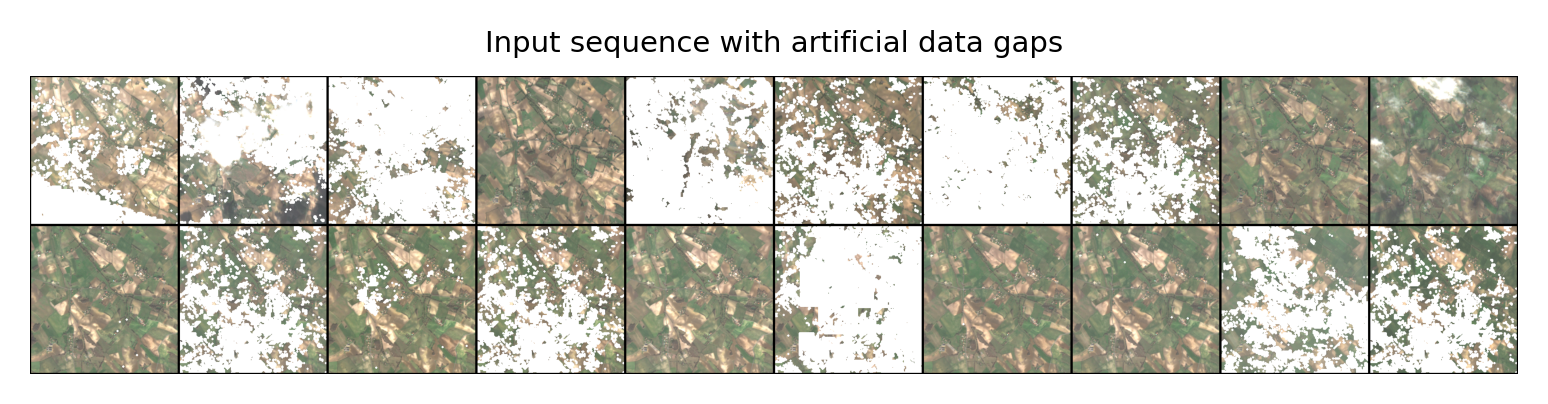

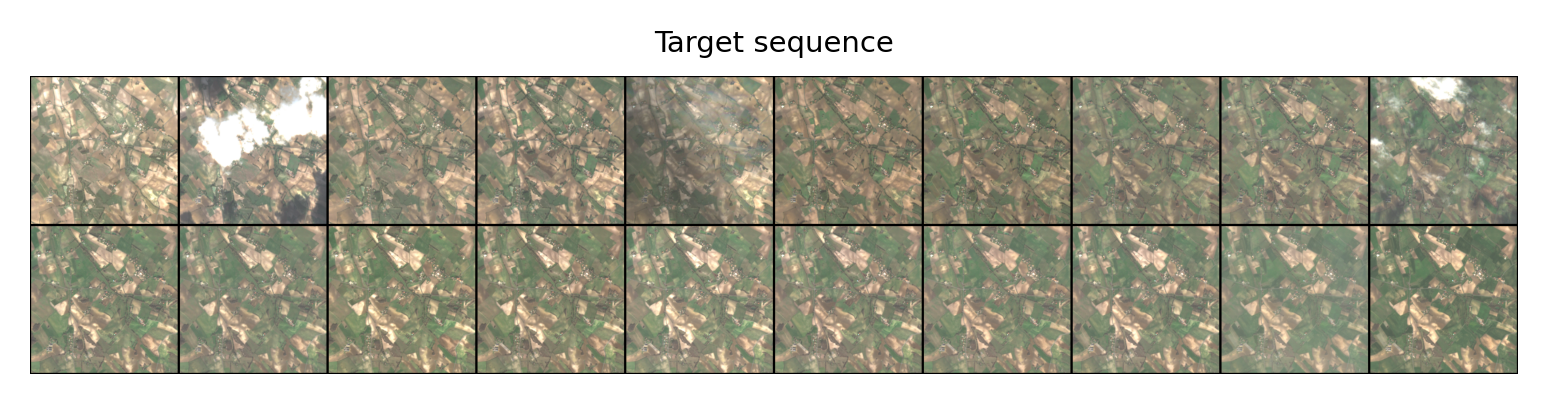

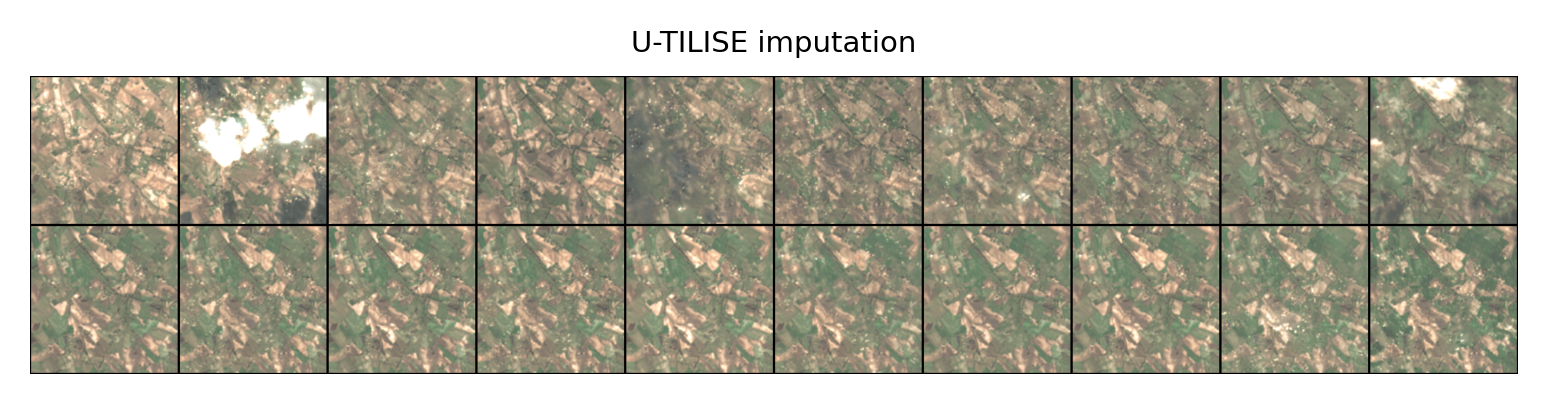

In [128]:
index = 0
sample = get_sample(test_loader, index)
batch, y_pred, att = inference_imputation.impute_sample(
    batch=sample,
    t_start=10,
    t_end=30,
    return_att=True,
)

# print("Analyse rapide des sorties de l'inférence:")
# print(sample.keys())
# print(sample["x"].shape)
# print(sample["y"].shape)
# print(sample.keys())
# print(y_pred.shape)
# print(batch.keys())
# print(batch["x"].shape)
# print(batch["y"].shape)

# Let's visualize the sequences
brightness_factor = 3
indices_rgb = batch['c_index_rgb'][0]

fig = visutils.sequence2gallery(batch['x'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Input sequence with artificial data gaps', fontsize=7)

fig = visutils.sequence2gallery(batch['y'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Target sequence', fontsize=7)

fig = visutils.sequence2gallery(y_pred[0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('U-TILISE imputation', fontsize=7)

### Calcul de métrique pour une inférence

In [105]:
from lib.metrics import EvalMetrics
compute_metrics = EvalMetrics(training_config_file.metrics)
metrics_on_sample = compute_metrics(batch, y_pred)
print("**Metrics on the sample:**")
for k, v in metrics_on_sample.items():
    print(f"{k}: {v:.4f}")

**Metrics on the sample:**
ssim: 0.9621
masked_mae: 0.0084
masked_rmse: 0.0115
masked_mse: 0.0001
masked_psnr: 38.7729
masked_sam: 0.0322


In [130]:
y_pred.shape

torch.Size([1, 20, 10, 256, 256])